# 1. Dataset Loading and Preprocessing

In [2]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

# 1. Define Transforms (Use Bicubic and ImageNet stats as per Swin Paper)
# Training uses heavy augmentation to prevent overfitting
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test use simple Resize and CenterCrop
eval_transform = transforms.Compose([
    transforms.Resize(232, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load Dataset
full_dataset = datasets.ImageFolder(root='/content/drive/MyDrive/dat', transform=train_transform)

# 3. Split into Train (80%), Val (10%), and Test (10%)
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_data, val_data, test_data = random_split(full_dataset, [train_size, val_size, test_size])

# Apply eval_transform to val/test sets (manually override for those subsets)
val_data.dataset.transform = eval_transform
test_data.dataset.transform = eval_transform

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# 2. Model, Optimizer, and Loss

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Pre-trained Swin-T
model = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)
num_classes = len(full_dataset.classes)
model.head = torch.nn.Linear(model.head.in_features, num_classes)
model.to(device)

# Loss and Optimizer
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1) # Smoothing helps overfitting
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 185MB/s] 


# 3. Training and Validation Loops

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Storage for plotting
history = {
    "train_loss": [],
    "train_acc":[],
    "val_loss": [],
    "val_acc": []
}


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).type(torch.float).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def validate(model, loader, criterion):
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).type(torch.float).sum().item()
    return val_loss / len(loader), correct / len(loader.dataset)

# Main Loop
for epoch in range(10):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    # Store history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}:Train Acc: {train_acc:.4f} Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}--- Val_loss: {val_loss:.3f}")
    scheduler.step()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1:Train Acc: 0.9187 Train Loss: 0.3186 | Val Acc: 1.0000--- Val_loss: 0.221


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2:Train Acc: 0.9989 Train Loss: 0.2138 | Val Acc: 1.0000--- Val_loss: 0.209


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch 8:Train Acc: 1.0000 Train Loss: 0.2007 | Val Acc: 1.0000--- Val_loss: 0.202


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 9:Train Acc: 1.0000 Train Loss: 0.2010 | Val Acc: 1.0000--- Val_loss: 0.202


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 10:Train Acc: 1.0000 Train Loss: 0.2010 | Val Acc: 1.0000--- Val_loss: 0.203


# 2. Visualizing Training and Validation Loss

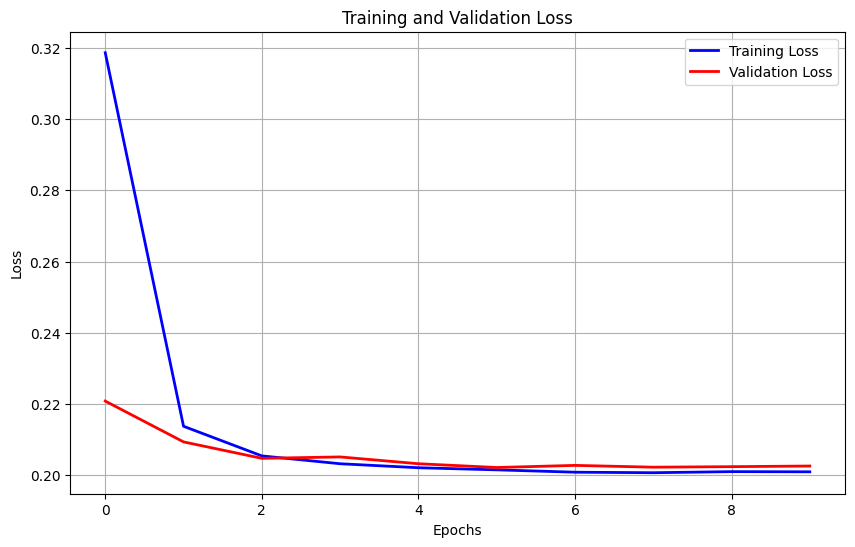

In [5]:
def plot_loss(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history["train_loss"], label='Training Loss', color='blue', lw=2)
    plt.plot(history["val_loss"], label='Validation Loss', color='red', lw=2)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(history)

# 3. Visualizing the Confusion Matrix

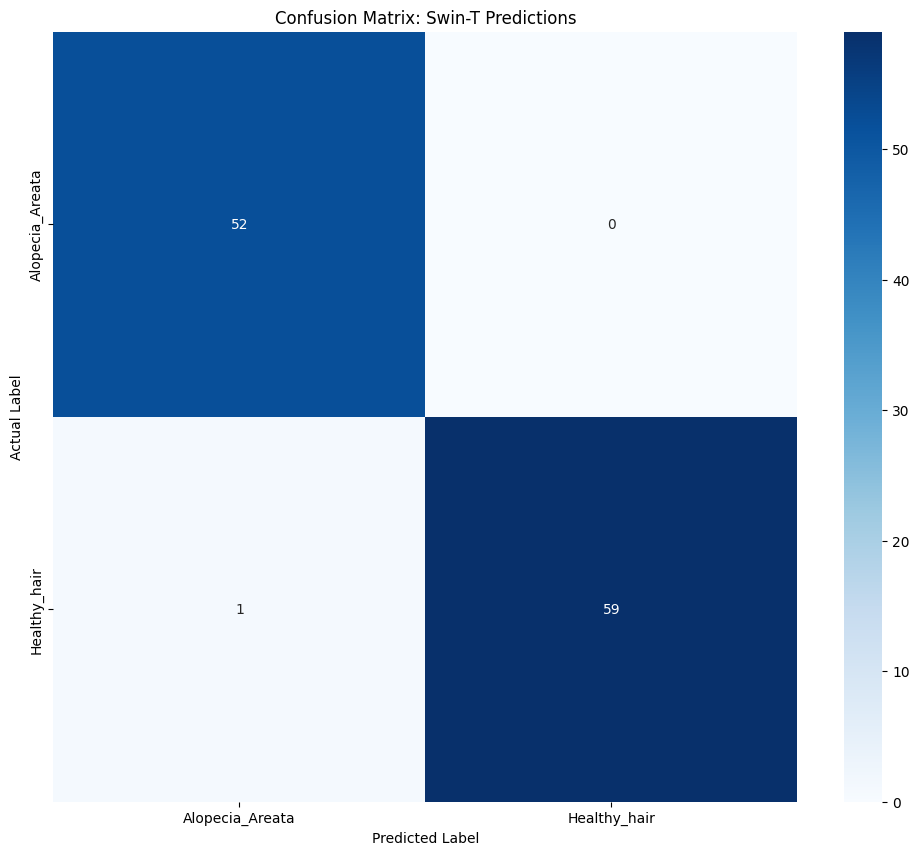

In [6]:
def plot_confusion_matrix(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Calculate CM
    cm = confusion_matrix(all_labels, all_preds)

    # Plot using Seaborn
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix: Swin-T Predictions')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Usage (assuming test_loader.dataset.classes contains your labels)
plot_confusion_matrix(model, test_loader, full_dataset.classes)

# 4. Final Testing

In [7]:
def test_model(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            correct += (outputs.argmax(1) == labels).type(torch.float).sum().item()
    print(f"Final Test Accuracy: {100 * correct / len(loader.dataset):.2f}%")

test_model(model, test_loader)
from torchsummary import summary
# from torchviz import make_dot
# vgg = models.vgg16()
summary(model, (3, 224, 224))
# make_dot(model, params=dict(model.named_parameters()))

Final Test Accuracy: 99.11%
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 56, 56]           4,704
           Permute-2           [-1, 56, 56, 96]               0
         LayerNorm-3           [-1, 56, 56, 96]             192
         LayerNorm-4           [-1, 56, 56, 96]             192
ShiftedWindowAttention-5           [-1, 56, 56, 96]               0
   StochasticDepth-6           [-1, 56, 56, 96]               0
         LayerNorm-7           [-1, 56, 56, 96]             192
            Linear-8          [-1, 56, 56, 384]          37,248
              GELU-9          [-1, 56, 56, 384]               0
          Dropout-10          [-1, 56, 56, 384]               0
           Linear-11           [-1, 56, 56, 96]          36,960
          Dropout-12           [-1, 56, 56, 96]               0
  StochasticDepth-13           [-1, 56, 56, 96]               0
SwinTra

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      1.00      0.99        52
    Alopecia       1.00      0.98      0.99        60

    accuracy                           0.99       112
   macro avg       0.99      0.99      0.99       112
weighted avg       0.99      0.99      0.99       112

ROC-AUC Score: 1.0000


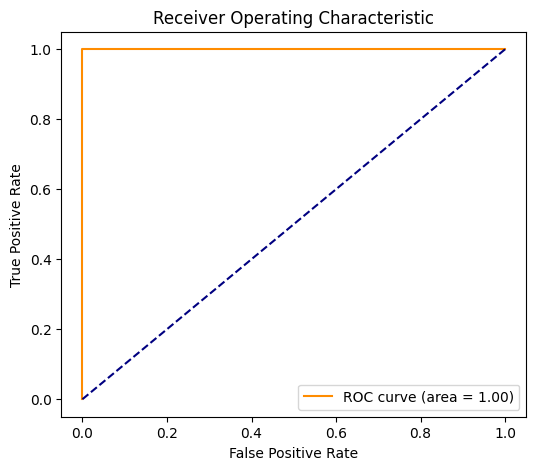

In [8]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Get probabilities using Softmax for ROC
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # 1. Precision, Recall, F1-Score
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Healthy', 'Alopecia']))

    # 2. ROC-AUC (using probabilities for the positive class)
    # Assuming Alopecia is class 1
    prob_positive_class = np.array(all_probs)[:, 1]
    auc_score = roc_auc_score(all_labels, prob_positive_class)
    print(f"ROC-AUC Score: {auc_score:.4f}")

    # 3. Plot ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, prob_positive_class)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    # return all_preds, all_labels

evaluate_model(model, test_loader, device)

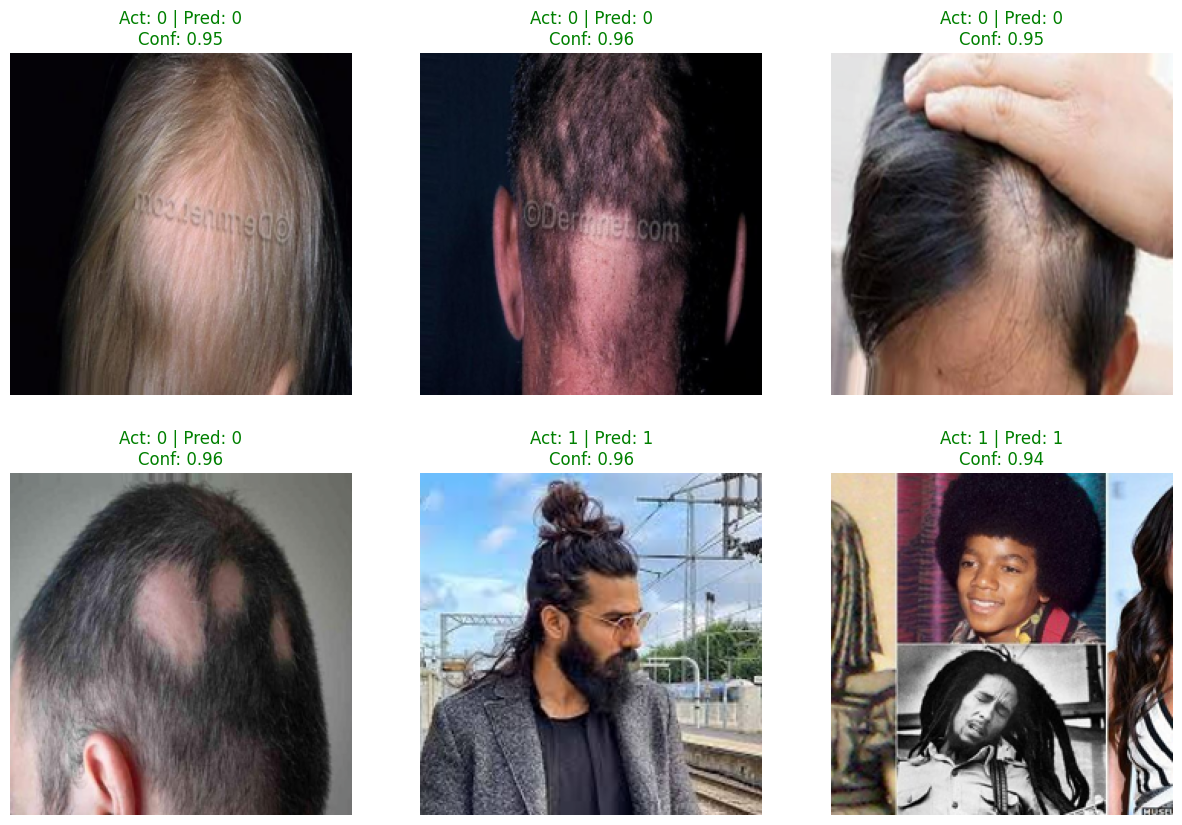

In [9]:
def plot_predictions(model, test_loader, device, num_images=6):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    probs = torch.nn.functional.softmax(outputs, dim=1)
    conf, preds = torch.max(probs, 1)

    plt.figure(figsize=(15, 10))
    for i in range(num_images):
        plt.subplot(2, 3, i + 1)
        # Un-normalize for visualization
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

        color = 'green' if preds[i] == labels[i] else 'red'
        plt.imshow(img)
        plt.title(f"Act: {labels[i].item()} | Pred: {preds[i].item()}\nConf: {conf[i].item():.2f}", color=color)
        plt.axis('off')
    plt.show()
plot_predictions(model, test_loader, device, num_images=6)


## 5. Save the Model

In [10]:
model_save_path = 'swin_t_alopecia_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to swin_t_alopecia_model.pth


## 6. Using the Saved Model for Inference

In [ ]:
import torch
from torchvision import transforms, models
from PIL import Image
import requests
from io import BytesIO

# 1. Re-initialize the model architecture
# Make sure this matches the architecture you trained
loaded_model = models.swin_t(weights=None)  # No pre-trained weights initially
num_classes = len(full_dataset.classes) # Use the same number of classes
loaded_model.head = torch.nn.Linear(loaded_model.head.in_features, num_classes)

# 2. Load the saved state_dict
model_save_path = 'swin_t_alopecia_model.pth'
loaded_model.load_state_dict(torch.load(model_save_path, map_location=device))
loaded_model.to(device)
loaded_model.eval() # Set model to evaluation mode

print("Model loaded successfully!")

Model loaded successfully!



Prediction for the image:
Predicted Class: Alopecia_Areata
Confidence: 0.9452
Actual Class (from test_loader): Alopecia_Areata


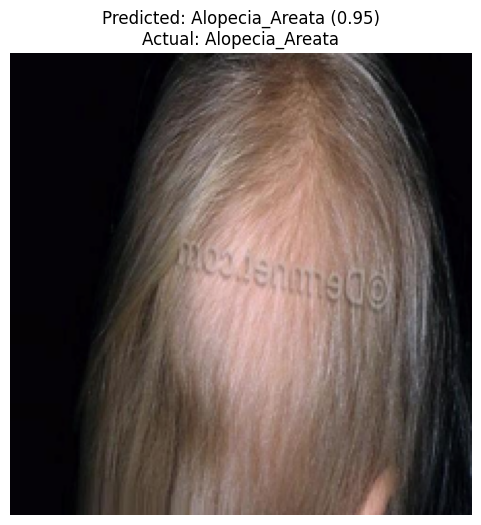

In [12]:
# 3. Define the same evaluation transformations
# This needs to be exactly the same as during training/validation for new images
inference_transform = transforms.Compose([
    transforms.Resize(232, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Load a new image (example from a URL, replace with your image path)
# For demonstration, let's use a placeholder image or a URL if available
# You would replace this with your actual image loading logic

# Example: Downloading an image from a URL (replace with a suitable image)
# If you have a local image, you can use Image.open('path/to/your/image.jpg')

# Placeholder for a sample image (you should replace this with an actual image relevant to your classes)
# For instance, a URL for a 'healthy' or 'alopecia' image if available publicly
# Or, if you have a local image from your dataset, use Image.open('/content/drive/MyDrive/dat/healthy/some_image.jpg')

# Let's assume you want to test with an image from your test_loader if you don't have a new one readily available
# Otherwise, you would provide a new image path or URL.

# For demonstration, taking one image from the test_loader
# Note: If you want to test a completely new image, replace this section.

# First, let's get the class names for interpreting predictions
class_names = full_dataset.classes

# Option 1: Load a local image (replace with your path)
# image_path = '/content/drive/MyDrive/dat/test_images/sample_alopecia.jpg' # example path
# try:
#     image = Image.open(image_path).convert('RGB')
#     print(f"Loaded image from {image_path}")
# except FileNotFoundError:
#     print(f"Error: Image not found at {image_path}. Please provide a valid path.")
#     image = None

# Option 2: Use an image from the existing test_loader for demonstration
# This assumes test_loader is still available and has data

# Get one sample from the test_loader
example_images, example_labels = next(iter(test_loader))
sample_image_tensor = example_images[0] # Take the first image
sample_true_label = example_labels[0].item()

# Convert tensor back to PIL Image for consistent processing
# Unnormalize and convert to PIL Image
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Create an inverse transform if needed, but for display, direct unnormalization is often easier
img_np = sample_image_tensor.cpu().numpy().transpose((1, 2, 0))
img_np = (img_np * std + mean) # Reverse normalization
img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)
image = Image.fromarray(img_np)


if image:
    # 5. Preprocess the image
    input_tensor = inference_transform(image)
    input_batch = input_tensor.unsqueeze(0)  # Add a batch dimension

    # 6. Move to device and make prediction
    input_batch = input_batch.to(device)
    with torch.no_grad():
        output = loaded_model(input_batch)

    # Get probabilities and predicted class
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    predicted_prob, predicted_idx = torch.max(probabilities, 0)
    predicted_class = class_names[predicted_idx.item()]

    # 7. Print results
    print(f"\nPrediction for the image:")
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {predicted_prob.item():.4f}")
    print(f"Actual Class (from test_loader): {class_names[sample_true_label]}")

    # 8. Display the image with prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class} ({predicted_prob.item():.2f})\nActual: {class_names[sample_true_label]}")
    plt.axis('off')
    plt.show()
else:
    print("No image loaded for inference.")